# Change over time by age group in Aruba

This...

## Data Source
- **Source: Central Bureau of Statistics Aruba**
- **Dataset(s):** Key demographic aspects.xlsx and Table-1.9-Relative-population-by-age-groups-in-percentage.xlsx
- **Period:** 2015–2023 (Note: 2015 has no baseline and is excluded from analysis)

## Method
Establish baseline population trends before examining population change
and migration drivers in subsequent notebooks.

## Overview

This notebook is structured as follows:

1. **Setup & Configuration** — Import libraries and establish file paths
2. **Data Loading & Exploration** — Load CBS datasets and examine their structure
3. **Analysis & Visualization** — Transform data, calculate trends, and visualize findings

---
# **Import libraries and set path**

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Establish path(s)
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

from config.project_paths import (
    ROOT,
    DATA_RAW,
    DATA_PROCESSED,
    FIGURES,
    YEAR_MIN,
    YEAR_MAX,
    get_raw_data_path,
    get_processed_data_path,
    get_figure_path,
    validate_paths,
)

In [2]:
# Verify all paths
print("ROOT:", ROOT)
print("RAW DATA:", DATA_RAW)
print("PROCESSED DATA:", DATA_PROCESSED)
print("FIGURES:", FIGURES)

ROOT: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1
RAW DATA: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/raw
PROCESSED DATA: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/processed
FIGURES: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/outputs/figures


---
**Load data set and test for errors**
---

In [3]:
# Load raw data
RAW_DEMOGRAPHIC_ASPECTS_FILE = get_raw_data_path("Demographic-aspects-2023.xlsx")
TABLE_1_9 = get_raw_data_path("Table-1.9-Relative-population-by-age-groups-in-percentage.xlsx")

validate_paths({
    "Demographic aspects": RAW_DEMOGRAPHIC_ASPECTS_FILE,
    "Table-1.9-Relative-population-by-age-groups-in-percentage":TABLE_1_9
})

In [4]:
# Load raw data
# Both sheets use row 1 (0-indexed) as the real header → header=1
df_main = pd.read_excel("/home/ggirelli/Documents/DataAnalysis/Datasets/Spreadsheets/Official_Open-Datasets_Aruba_CBS/Demographic-aspects-2023.xlsx", header=1)
df2_to_merge = pd.read_excel("/home/ggirelli/Documents/DataAnalysis/Datasets/Spreadsheets/Official_Open-Datasets_Aruba_CBS/Table-1.9-Relative-population-by-age-groups-in-percentage.xlsx", header=1)

In [5]:
# Clean df_main → extract total population per year
# Normalise the text column to avoid invisible-whitespace mismatches
df_main["Key Demographic aspects"] = (
    df_main["Key Demographic aspects"].astype(str).str.strip()
)

df_total_row = df_main[df_main["Key Demographic aspects"] == "Total population"]

In [6]:
df_total_row

,Key Demographic aspects,Unit,2015,2016,2017,2018,2019,2020,2021,2022,2023
2,Total population,Absolute,108635.0,108818.0,108651.0,109164.0,109241.0,107932.0,107468.0,107152.0,107566.0


In [7]:
# Melt from wide → long; years become rows
df_total_tidy = df_total_row.melt(
    id_vars=["Key Demographic aspects", "Unit"],
    var_name="Year",
    value_name="Total_Count"
)

In [8]:
# Keep only the two columns we need downstream
df_total_tidy = df_total_tidy[["Year", "Total_Count"]]
df_total_tidy["Year"] = df_total_tidy["Year"].astype(int)

print("── df_total_tidy ──")
print(df_total_tidy.to_string(index=False))

── df_total_tidy ──
 Year  Total_Count
 2015     108635.0
 2016     108818.0
 2017     108651.0
 2018     109164.0
 2019     109241.0
 2020     107932.0
 2021     107468.0
 2022     107152.0
 2023     107566.0


In [9]:
# Clean df_to_merge → age-group percentages per sex per year
# The raw sheet has a two-row header:
# Row 0 (after header=1 read): year numbers (2015 … 2023), every 3rd column
# Row 1 (actual data row 0):   sub-labels "Male", "Female", "Total"
# Strategy: rename ALL columns explicitly, then drop the sub-label row.

years = range(2015, 2024)

new_cols = ["Age"]
for y in years:
    new_cols += [f"Male_{y}", f"Female_{y}", f"Total_{y}"]  # 9 × 3 = 27 cols + Age = 28

df2_to_merge.columns = new_cols          # overwrite the messy auto-generated names
df2 = df2_to_merge.iloc[1:].copy()       # drop row 0 (the "Male / Female / Total" sub-header)

# Keep only the meaningful age-band rows; discard ratio/footnote rows
keep_ages = ["0 - 14", "15 - 59", "60 +", "Total"]
df2_to_merge["Age"] = df2_to_merge["Age"].astype(str).str.strip()
df_age = df2_to_merge[df2_to_merge["Age"].isin(keep_ages)].reset_index(drop=True)

print("\n── df_age (wide, cleaned) ──")
print(df_age.to_string(index=False))


── df_age (wide, cleaned) ──
    Age Male_2015 Female_2015 Total_2015 Male_2016 Female_2016 Total_2016 Male_2017 Female_2017 Total_2017 Male_2018 Female_2018 Total_2018 Male_2019 Female_2019 Total_2019 Male_2020 Female_2020 Total_2020 Male_2021 Female_2021 Total_2021 Male_2022 Female_2022 Total_2022 Male_2023 Female_2023 Total_2023
 0 - 14       9.6         9.2       18.9       9.5         9.1       18.7       9.5           9       18.6       9.3         8.9       18.3       9.2         8.8       18.1       8.7         8.3         17       8.1         8.1       16.6       8.2         7.9       16.1       7.9         7.6       15.6
15 - 59      29.4        32.8       62.3      29.3        32.5       61.8      29.0        32.2       61.2      28.6          32       60.6      28.4        31.6         60      28.1        31.2       59.3      27.5        30.9       58.8      27.6        30.6       58.2      27.4        30.5       57.9
   60 +         8        10.6       18.7       8.3     

In [10]:
# Melt df_age → tidy long form
df_age_long = df_age.melt(
    id_vars=["Age"],
    var_name="Sex_Year",        # e.g. "Male_2015"
    value_name="Percentage"
)

In [11]:
# Split "Male_2015" into two columns → Sex="Male", Year=2015
df_age_long[["Sex", "Year"]] = (
    df_age_long["Sex_Year"].str.rsplit("_", n=1, expand=True)
)
df_age_long["Year"] = df_age_long["Year"].astype(int)
df_age_long["Percentage"] = pd.to_numeric(df_age_long["Percentage"], errors="coerce")
df_age_long = df_age_long.drop(columns=["Sex_Year"]).reset_index(drop=True)

print("\n── df_age_long (first 12 rows) ──")
print(df_age_long.head(12).to_string(index=False))


── df_age_long (first 12 rows) ──
    Age  Percentage    Sex  Year
 0 - 14         9.6   Male  2015
15 - 59        29.4   Male  2015
   60 +         8.0   Male  2015
  Total        47.2   Male  2015
 0 - 14         9.2 Female  2015
15 - 59        32.8 Female  2015
   60 +        10.6 Female  2015
  Total        52.7 Female  2015
 0 - 14        18.9  Total  2015
15 - 59        62.3  Total  2015
   60 +        18.7  Total  2015
  Total       100.0  Total  2015


In [12]:
# Merge both DataFrames on Year
df_final = df_age_long.merge(df_total_tidy, on="Year", how="left")

# Bonus column: back-calculate absolute counts from % × total
df_final["Abs_Count"] = (
    df_final["Percentage"] / 100 * df_final["Total_Count"]
).round(0).astype("Int64")   # Int64 supports NaN natively

In [13]:
# Tidy column order and sort
df_final = (
    df_final[["Year", "Age", "Sex", "Percentage", "Total_Count", "Abs_Count"]]
    .sort_values(["Year", "Age", "Sex"])
    .reset_index(drop=True)
)

In [14]:
# Quick sanity check
# For Sex=="Total", the three age groups should sum to ~100 %
check = df_final[(df_final["Sex"] == "Total") & (df_final["Age"] != "Total")].groupby("Year")["Percentage"].sum()
     
print("\n── Column sum per year (Sex='Total', should be 100) ──")
print(check)


── Column sum per year (Sex='Total', should be 100) ──
Year
2015    99.9
2016    99.9
2017    99.9
2018    99.8
2019    99.8
2020    99.8
2021    99.9
2022    99.8
2023    99.8
Name: Percentage, dtype: float64


In [15]:
# Filter to totals only, exclude the grand-total "Total" age row
plot_df = df_final[
    (df_final["Sex"] == "Total") & (df_final["Age"] != "Total")
]

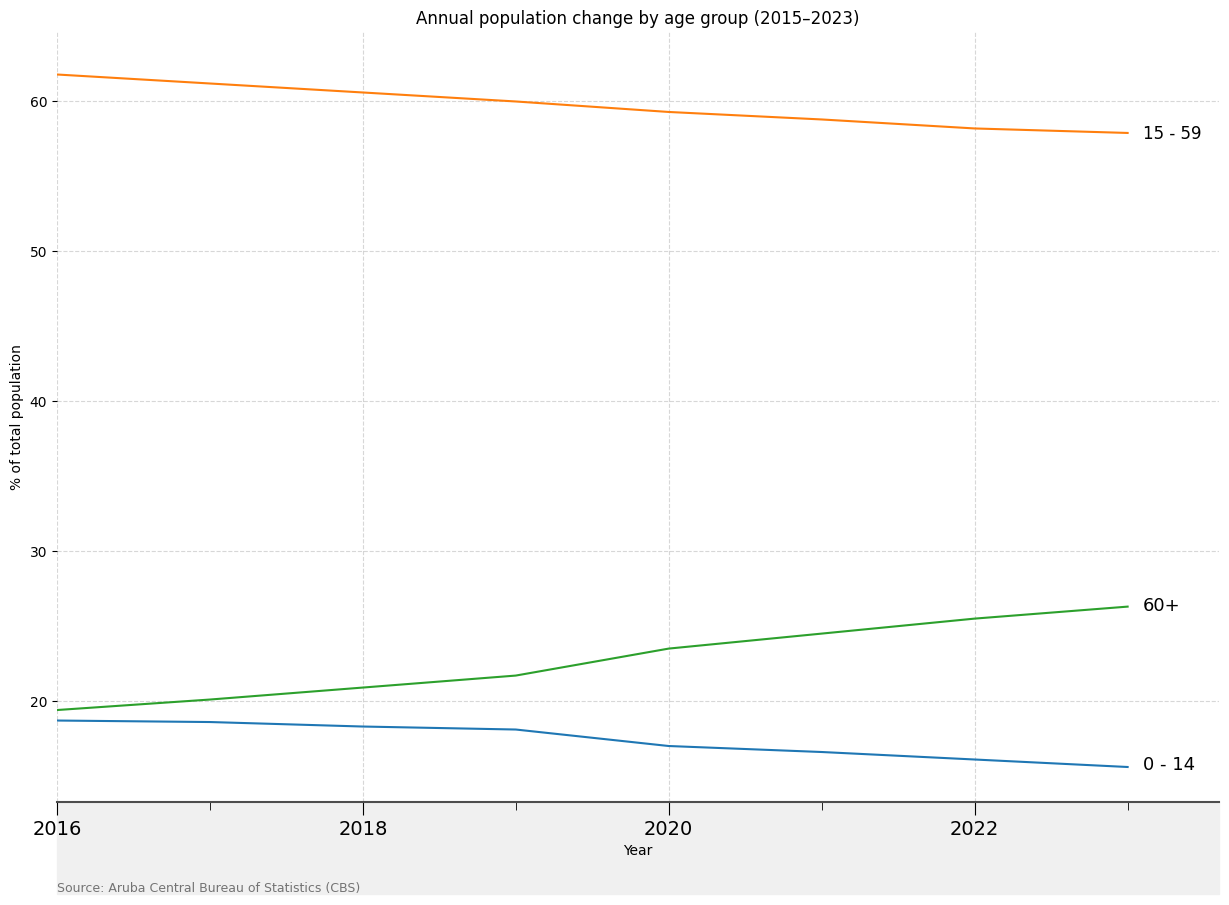

In [16]:
# Import Rectangle
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(15, 10))
for age, grp in plot_df.groupby("Age"):
    ax.plot(grp["Year"], grp["Percentage"], label=age)

ax.spines["left"].set_visible(False)

# Plot
ax.grid(True, alpha=0.25)

plt.figtext(
    0.125,
    0.02,
    "Source: Aruba Central Bureau of Statistics (CBS)",
    fontsize=9,
    color="0.45"
)

# Title
ax.set_title("Annual population change by age group (2015–2023)")

# X-axis
ax.set_xticks([2016, 2018, 2020, 2022])
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))

ax.spines["bottom"].set_linewidth(1.5)
ax.spines["bottom"].set_color("0.3")
ax.tick_params(axis="x" ,labelsize=14, which="major", length=9)
ax.tick_params(axis="x" ,labelsize=14, which="minor", length=6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# X-axis labels for total population, <= 14 and 60+
ax.set_xlim(2016, 2023.6)
ax.text(2023 + 0.1, 57.5, "15 - 59", fontsize=12) # 15 - 59.

ax.set_xlim(2016, 2023.8)
ax.text(2023 + 0.1, 26.0, "60+", fontsize=13) # 60+

ax.set_xlim(2016, 2023.6)
ax.text(2023 + 0.1, 15.4, "0 - 14", fontsize=13) # <= 14

# Grey band behind x-axis
rect = Rectangle(
    (0, -0.12),
    1,             # width (full axis)
    0.12,          # height of the band
    transform=ax.transAxes,
    color="0.94",
    zorder=0,
    clip_on=False
)

ax.add_patch(rect)

ax.set_ylabel("% of total population")
ax.set_xlabel("Year")
ax.grid(True, linestyle="--", alpha=0.5)

# Save figure
plt.savefig(("change_age_groups.png"), dpi=300, bbox_inches="tight")

plt.show()